In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install flowio

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for flowio: filename=flowio-1.4.0-py3-none-any.whl size=21897 sha256=20cebbc8970ed4343a158336ab487a7e66cfa40dfe6c8251ce4bf37517f1677a
  Stored in directory: /root/.cache/pip/wheels/85/ac/b0/1e3bf1774da784e601a026a80622d0a25979d52ef416c0e027
Successfully built flowio


In [3]:
import shutil
import pandas as pd
import random

import copy
import numpy as np # Import numpy for checking finite values
import matplotlib.pyplot as plt # Import matplotlib for potential debugging

import os
import os

import math # Import math for ceil
from sklearn.manifold import TSNE # Import TSNE to check default perplexity

import os
import glob
import json
import numpy as np

#import tensorflow as tf
import sys
from itertools import zip_longest

from sklearn import metrics
import pickle as pkl

In [21]:
import sys
#fixed_path = 'C:\\Users\\Enrico Didoli\\0.Master_Thesis\\'
#fixed_path = 'C:\\Users\\admin\\0.Master_Thesis\\'
fixed_path = '/content/drive/MyDrive/0.Master_Thesis/'
#fixed_path = '/mnt/c/Users/Enrico Didoli/0.Master_Thesis/'  # Controlla che il nome utente sia giusto!
#fixed_path = '/home/enrico/0.Master_Thesis/'

if fixed_path not in sys.path:
    sys.path.append(fixed_path)

cellcnn_path = f'{fixed_path}CellCNN/Ubuntu/'
if cellcnn_path not in sys.path:
    sys.path.append(cellcnn_path)

general_functions_path = f'{fixed_path}General_Functions/'
if general_functions_path not in sys.path:
    sys.path.append(general_functions_path)

save_path = f'{fixed_path}CellCNN/Ubuntu/results/'
if save_path not in sys.path:
    sys.path.append(save_path)

modules_dir = f'{cellcnn_path}/New running ipynb/Final_notebooks/modules/'
if modules_dir not in sys.path:
    sys.path.append(modules_dir)

In [35]:
decache_files = ['timepoints_elaboration', 'results_elaboration', 'functions', 'show_results']

# Rimuovi il modulo specifico dalla cache
from timepoints_elaboration import remove_from_cache
remove_from_cache(decache_files)


from timepoints_elaboration import load_data

from functions import show_blast_distribution_perc

from show_results import retireve_samples_info, show_patients_samples_info



timepoints_elaboration rimosso dalla cache
results_elaboration rimosso dalla cache
functions rimosso dalla cache
show_results rimosso dalla cache


In [10]:
data_folder_dir = f'{fixed_path}B-ALL_Datasets'
extension = '*.csv'

multiple_donations, ALL_DATASETS = load_data(data_path = data_folder_dir, ext = extension)#, remove_control = True)


0.09
Elaborating file 0: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D15_2.csv
0.0
Elaborating file 1: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D78.csv
0.16
Elaborating file 2: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D15_1.csv
0.01
Elaborating file 3: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D29_1.csv
0.0
Elaborating file 4: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D71_1.csv
0.15
Elaborating file 5: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE12_D15_2.csv
0.0
Elaborating file 6: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE12_D29_1.csv
39.56
Elaborating file 7: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE2_D15_2.csv
15.06
E

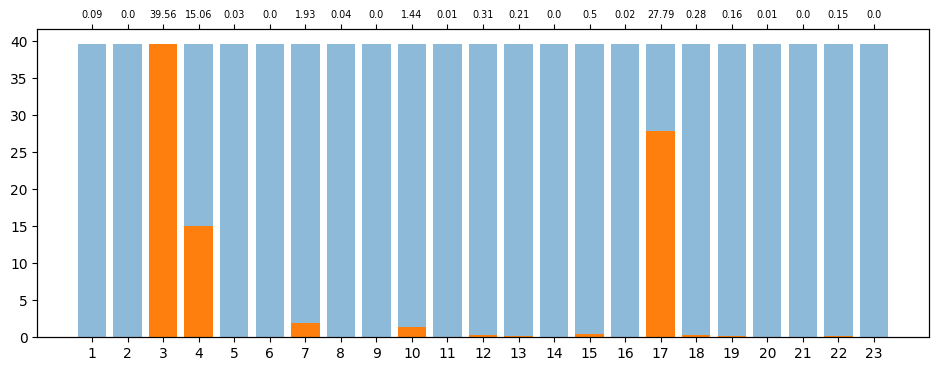

In [11]:
tot_perc_list = show_blast_distribution_perc(ALL_DATASETS,multiple_donations, return_perc = True)


/content/drive/MyDrive/0.Master_Thesis/CellCNN/Ubuntu//New running ipynb/Final_notebooks/modules/show_results.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


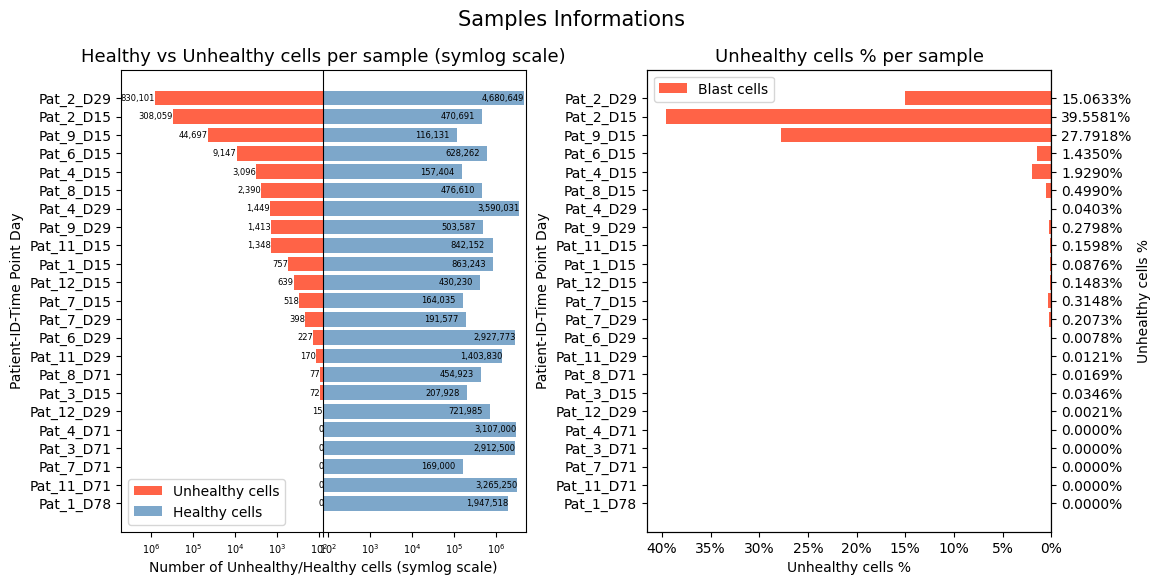

In [36]:

plot_exp = '5_fix_plots'

thesis_images_dir = f'{cellcnn_path}/experiments/experiment_{plot_exp}/thesis_images'
os.makedirs(thesis_images_dir, exist_ok=True)

samples_info_dict = retireve_samples_info(data_folder_dir, multiple_donations, ALL_DATASETS)
show_patients_samples_info(samples_info_dict, numbers = True)#, save_dir = thesis_images_dir)

In [13]:
samples_info_dict

,cells_n,healthy_n,blast_n,healthy_p,blast_p,patient_id,time_point_days,Sample
1,1947518,1947518,0,100.0,0.0,1,D78,1
4,3265250,3265250,0,100.0,0.0,11,D71,4
18,169000,169000,0,100.0,0.0,7,D71,18
10,2912500,2912500,0,100.0,0.0,3,D71,10
13,3107000,3107000,0,100.0,0.0,4,D71,13
6,722000,721985,15,99.9979,0.0021,12,D29,6
9,208000,207928,72,99.9654,0.0346,3,D15,9
20,455000,454923,77,99.9831,0.0169,8,D71,20
3,1404000,1403830,170,99.9879,0.0121,11,D29,3
15,2928000,2927773,227,99.9922,0.0078,6,D29,15


In [14]:
# info sample-specific per patient
for pat_id in samples_info_dict['patient_id'].unique():
    print('Patient:', pat_id)
    pat_rows = samples_info_dict[samples_info_dict['patient_id'] == pat_id]
    print(pat_rows.sort_index())
    print('')

Patient: 1
   cells_n healthy_n blast_n healthy_p blast_p patient_id time_point_days  \
0   864000    863243     757   99.9124  0.0876          1             D15   
1  1947518   1947518       0     100.0     0.0          1             D78   

   Sample  
0       0  
1       1  

Patient: 11
   cells_n healthy_n blast_n healthy_p blast_p patient_id time_point_days  \
2   843500    842152    1348   99.8402  0.1598         11             D15   
3  1404000   1403830     170   99.9879  0.0121         11             D29   
4  3265250   3265250       0     100.0     0.0         11             D71   

   Sample  
2       2  
3       3  
4       4  

Patient: 7
   cells_n healthy_n blast_n healthy_p blast_p patient_id time_point_days  \
16  164553    164035     518   99.6852  0.3148          7             D15   
17  191975    191577     398   99.7927  0.2073          7             D29   
18  169000    169000       0     100.0     0.0          7             D71   

    Sample  
16      16  
17  